In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, log_loss, classification_report

df = pd.read_csv("AI_Impact_on_Jobs_2030.csv")

df.head()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


In [3]:
def basic_eda(df, col):
    print(f"Shape of Dataset: {df.shape}")

    print(f"Info of the Datset: \n {df.info()}")

    print(f"Null Values Count: {df.isnull().sum()}")

    print(f"Duplicate Values Counts: {df.duplicated().sum()}")

    print(f"Skewness of the Dataset: \n {df.skew(numeric_only = True)}")

basic_eda(df, col = "Risk_Category")

Shape of Dataset: (3000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   fl

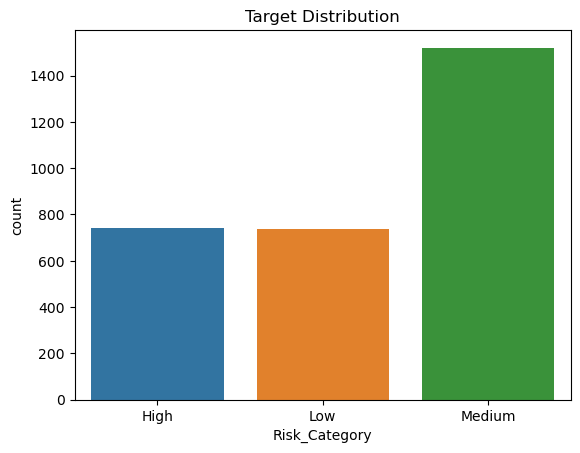

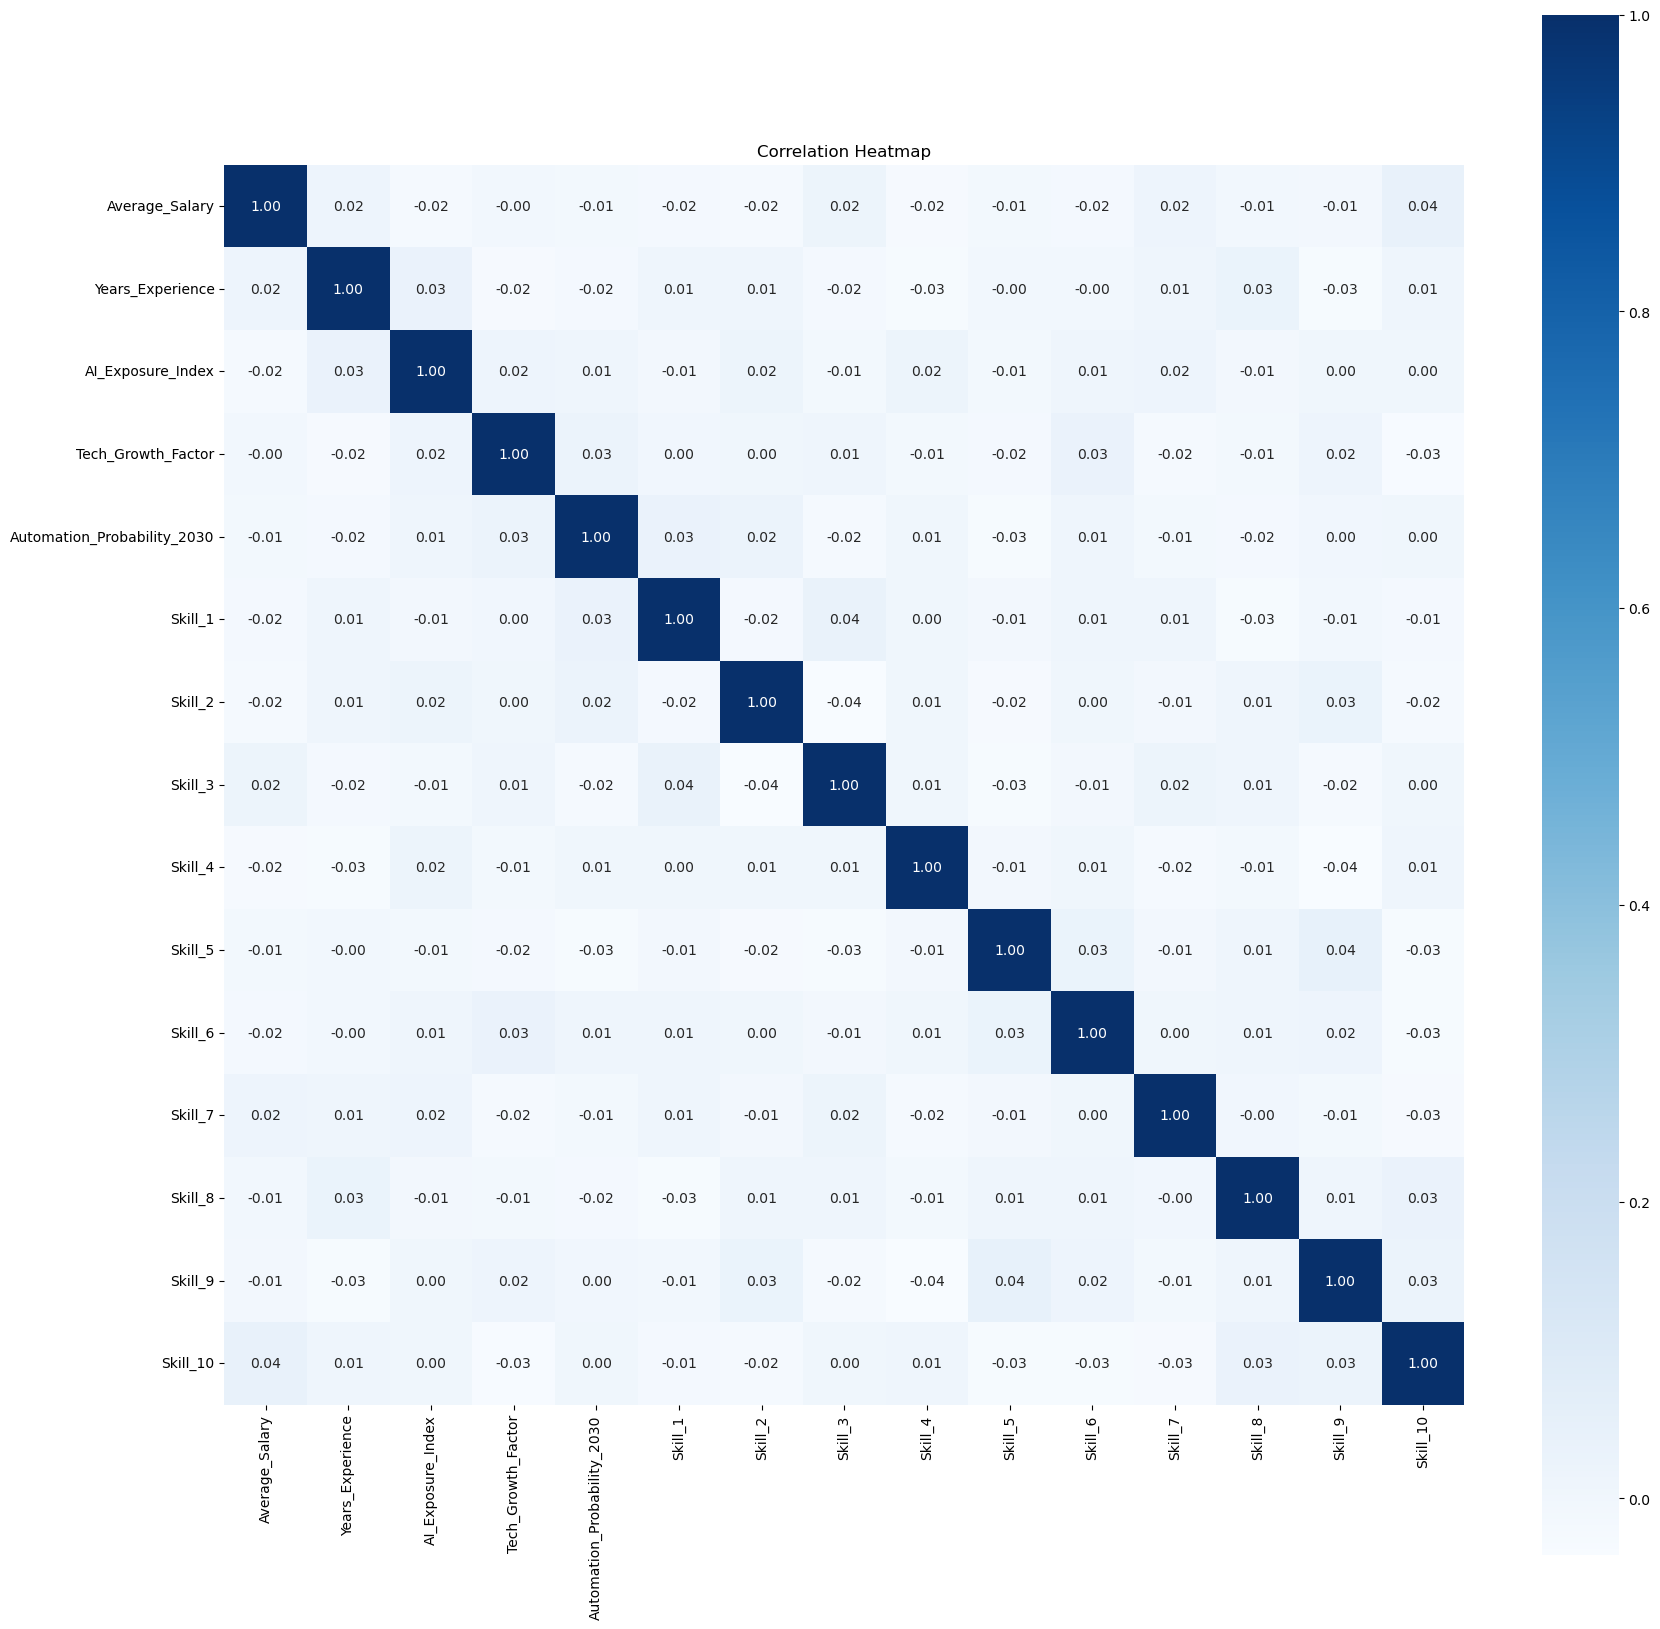

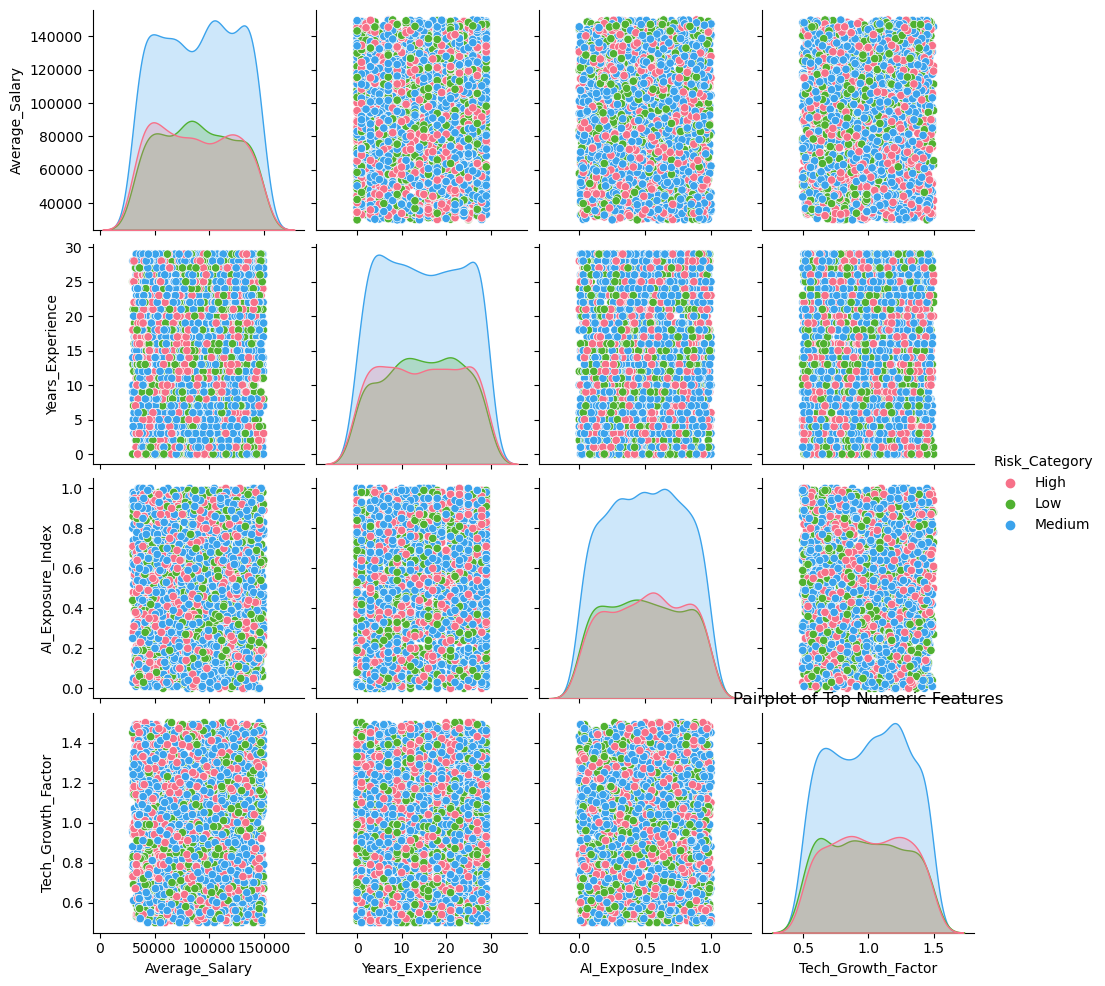

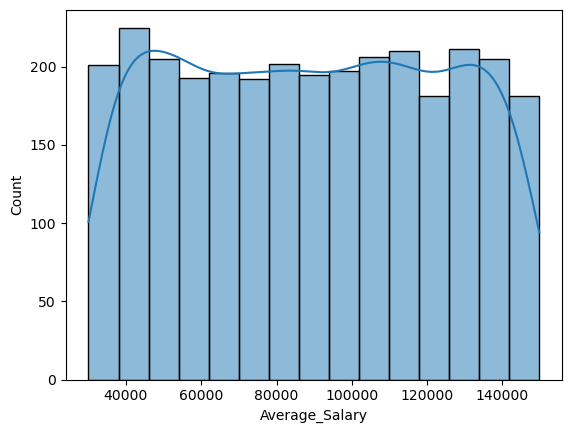

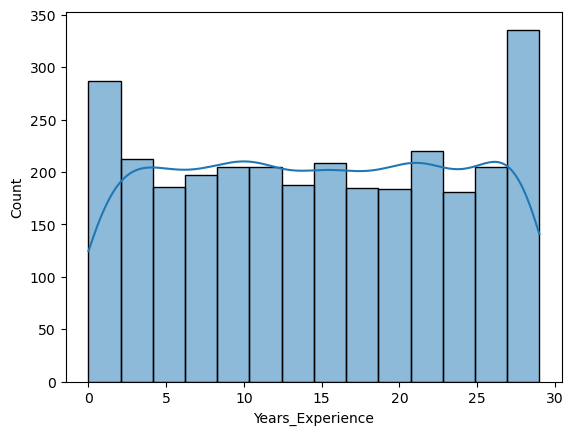

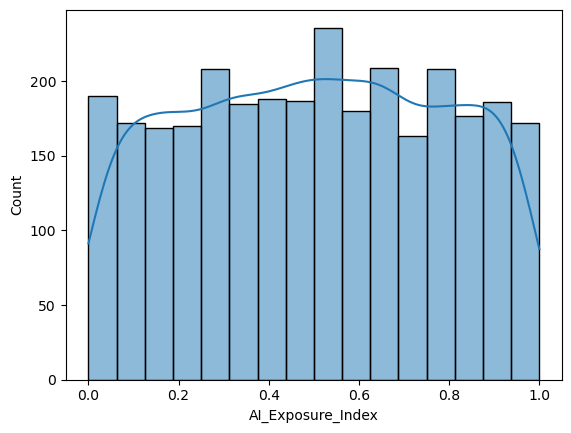

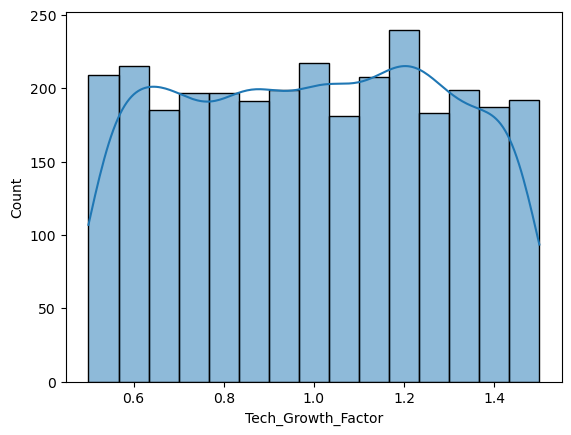

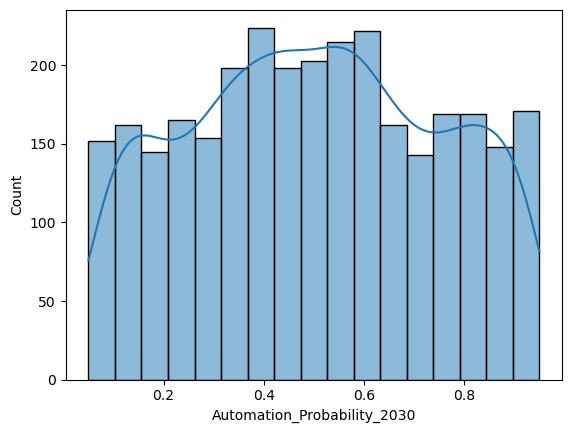

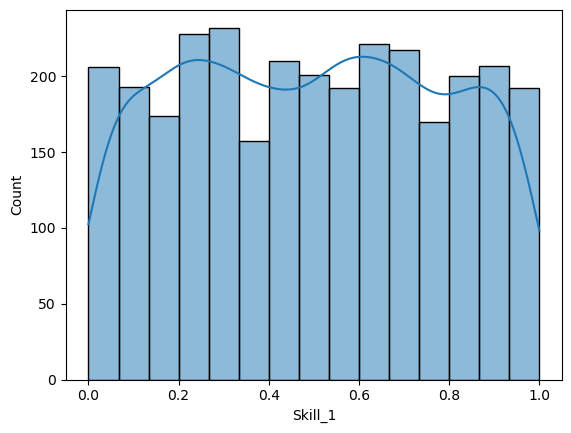

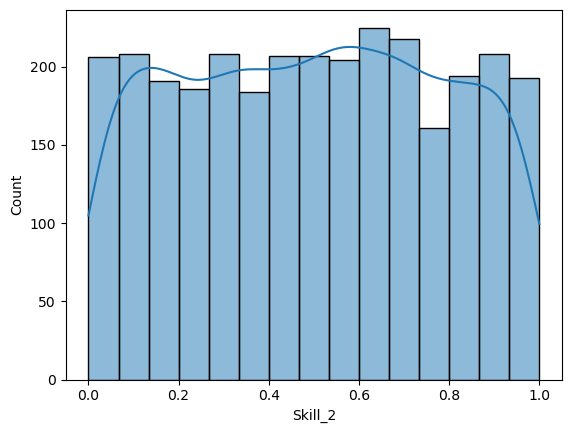

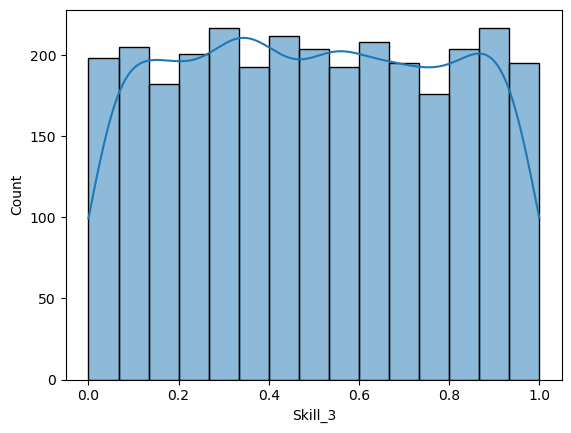

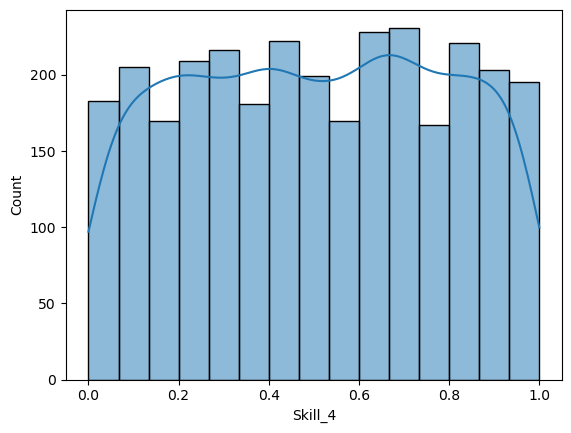

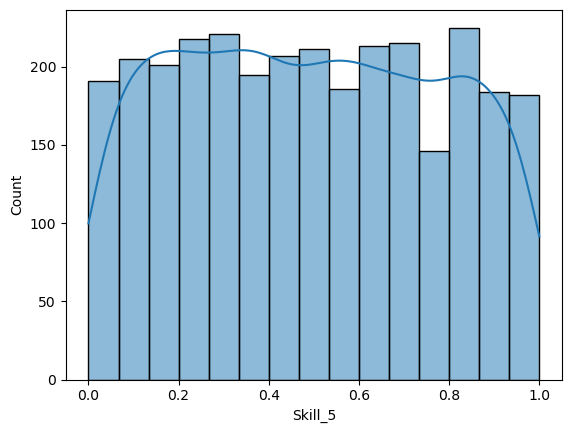

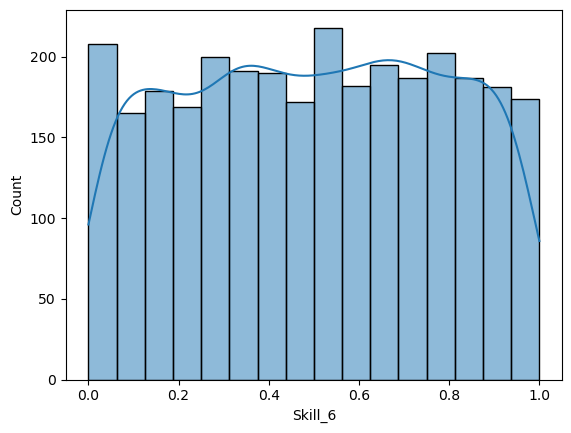

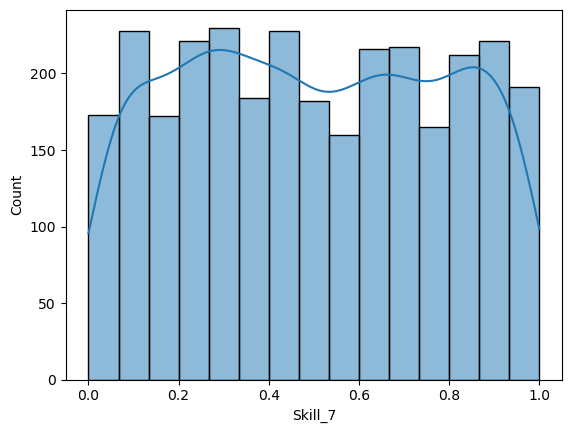

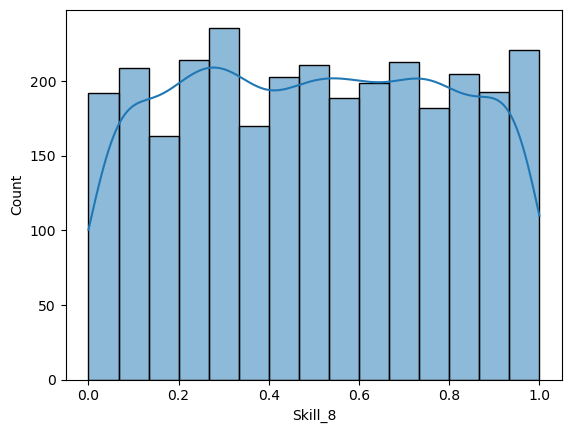

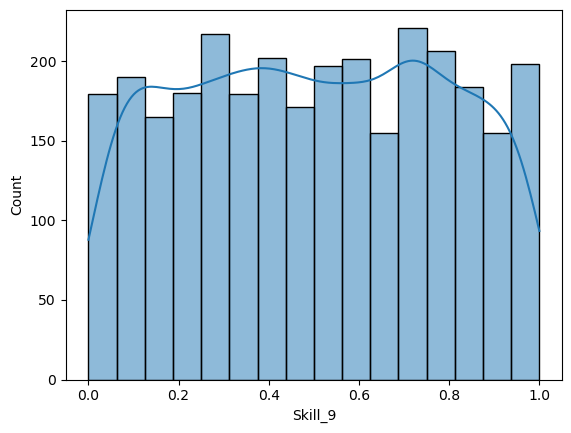

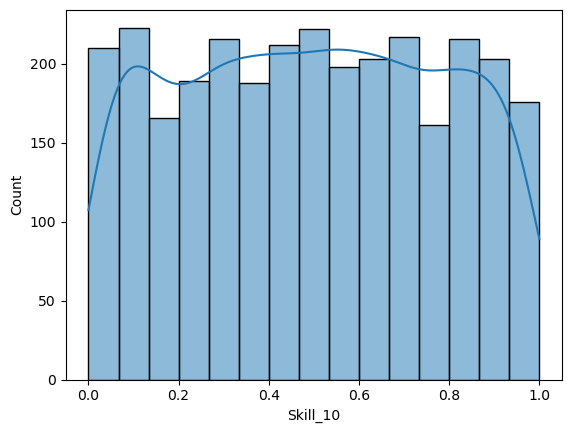

In [7]:
def basic_charting(df, col):
    num_cols = df.drop(columns = col).select_dtypes(include = ['int64', 'float64']).columns.tolist()
    top_num = num_cols[:4]

    sns.countplot(x = df[col])
    plt.title("Target Distribution"); plt.show()

    plt.figure(figsize = (20, 20))
    sns.heatmap(df.corr(numeric_only = True), annot = True, fmt = ".2f", cmap = "Blues", square = True)
    plt.title("Correlation Heatmap");plt.show()

    if len(top_num) > 1:
        sns.pairplot(df[top_num + [col]], hue = col, palette = 'husl')
        plt.title("Pairplot of Top Numeric Features");plt.show()

    for cols in num_cols:
        sns.histplot(df[cols], kde = True)
        plt.show()

basic_charting(df, col = "Risk_Category")

In [8]:
def outlier_checker(df, cols):
    num_cols = df.drop(columns = cols).select_dtypes(include = ['int64', 'float64']).columns.tolist()
    
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        print(f"{col}: {len(outliers)} outliers")
outlier_checker(df, cols = "Risk_Category")

Average_Salary: 0 outliers
Years_Experience: 0 outliers
AI_Exposure_Index: 0 outliers
Tech_Growth_Factor: 0 outliers
Automation_Probability_2030: 0 outliers
Skill_1: 0 outliers
Skill_2: 0 outliers
Skill_3: 0 outliers
Skill_4: 0 outliers
Skill_5: 0 outliers
Skill_6: 0 outliers
Skill_7: 0 outliers
Skill_8: 0 outliers
Skill_9: 0 outliers
Skill_10: 0 outliers


<Axes: xlabel='Job_Title', ylabel='count'>

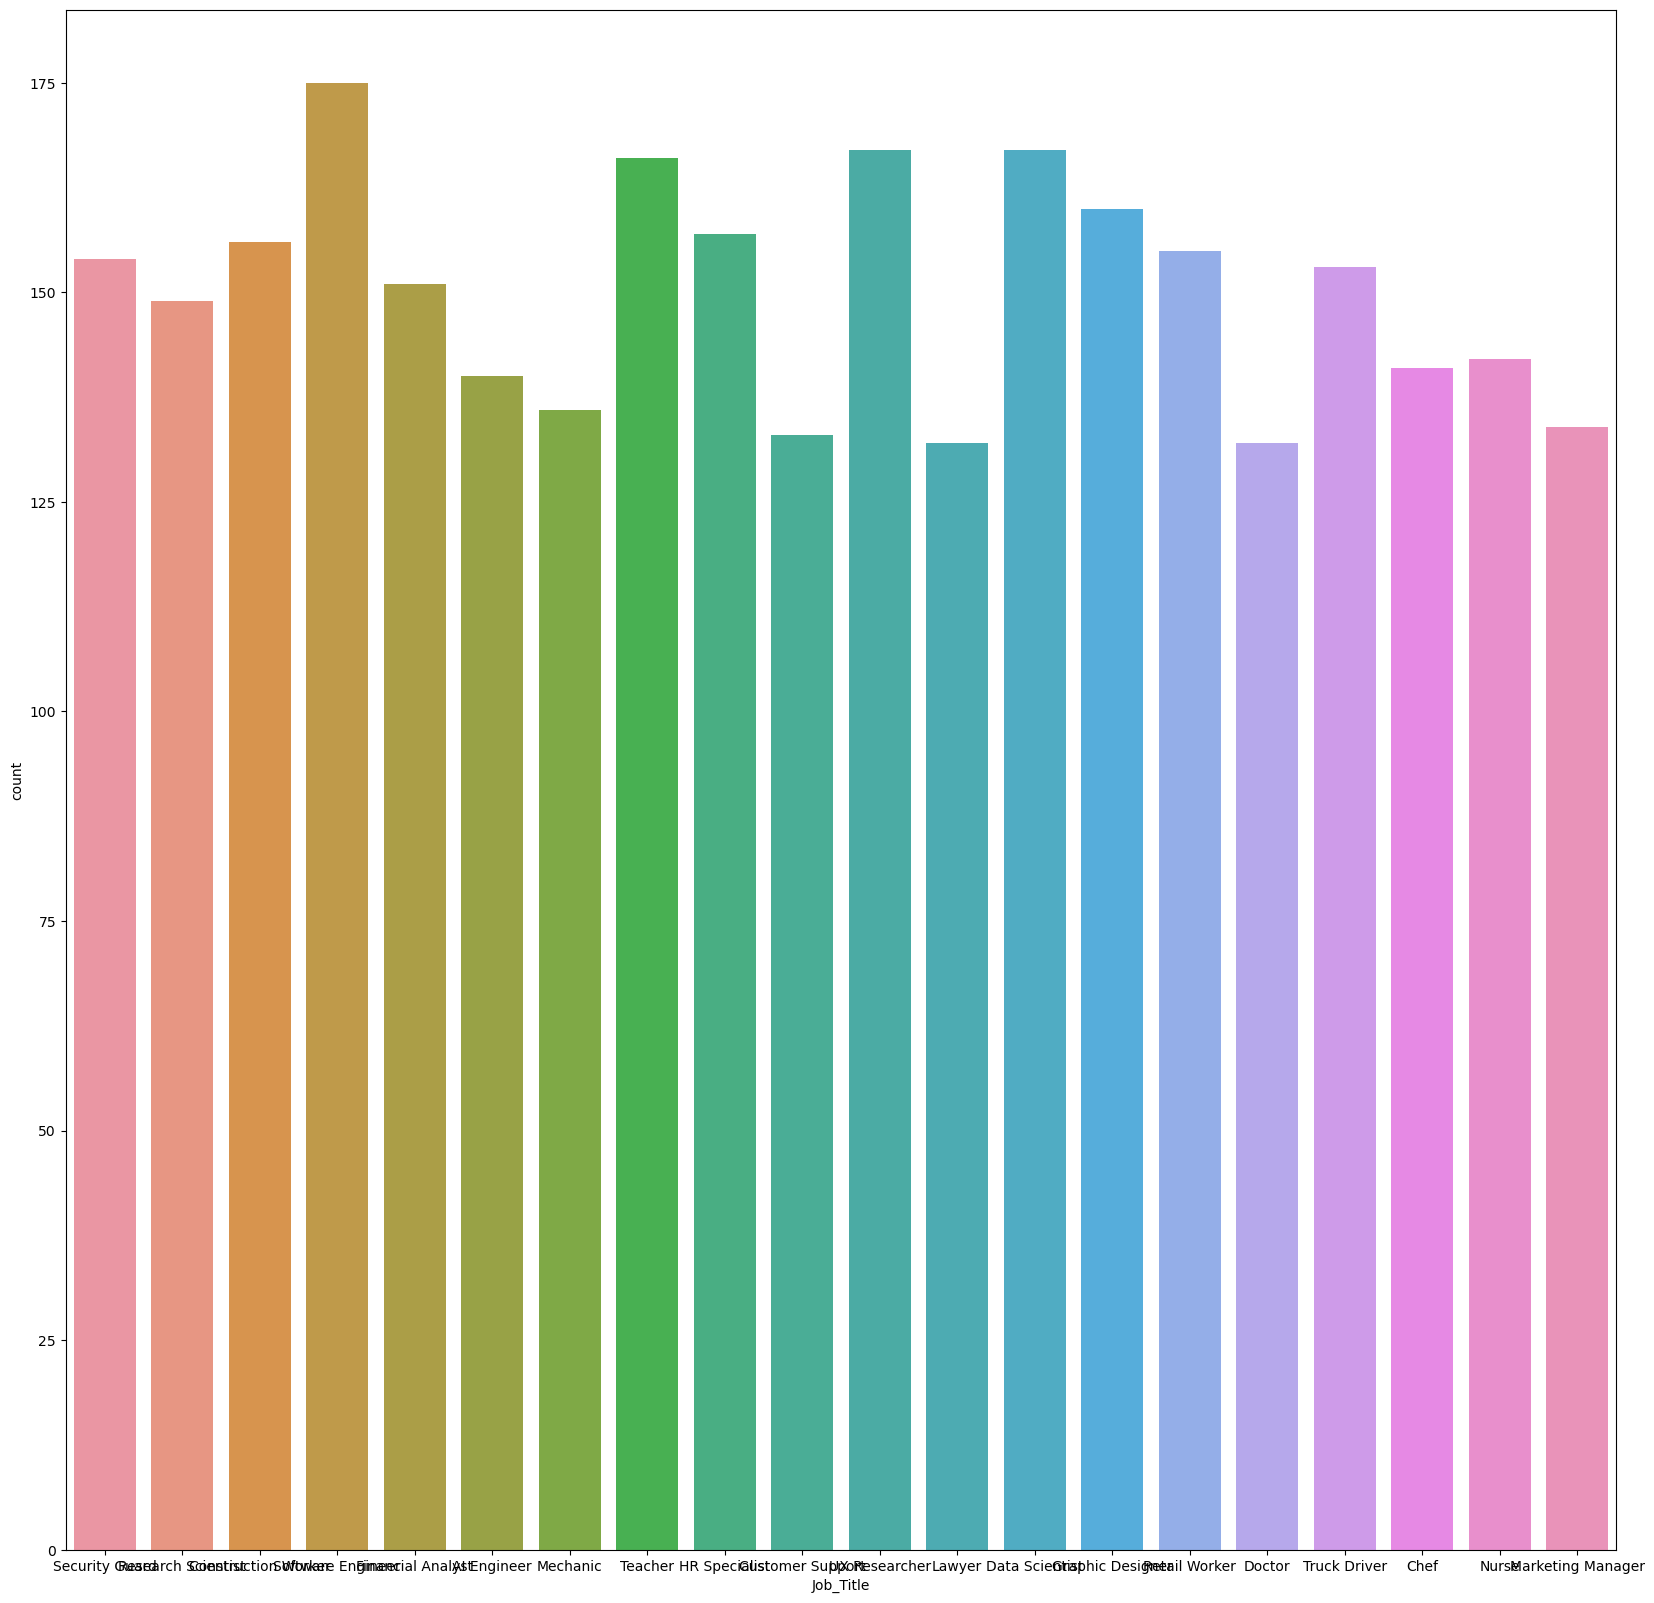

In [11]:
plt.figure(figsize = (20, 20))
sns.countplot(x = df["Job_Title"])

In [16]:
def data_preprocessing(df, col):
    X = df.drop(columns = col)
    y = df[col]

    num_cols = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include = ['object']).columns.tolist()
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ])
    return X, y, preprocessor

X, y, preprocesor = data_preprocessing(df, col = "Risk_Category")

In [17]:
def classification_model(X_train, y_train, preprocessor):
    model = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state = 42))
    ])

    param_grid = {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5]
    }

    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

    grid_search = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        cv = cv,
        scoring = "f1_weighted",
        n_jobs = -1
    )
    grid_search.fit(X_train, y_train)

    return grid_search.best_estimator_

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
best_model = classification_model(X_train, y_train, preprocesor)

Accuracy Score: 1.0
Precision Score: 1.0
Recall Score: 1.0
F1-Score: 1.0


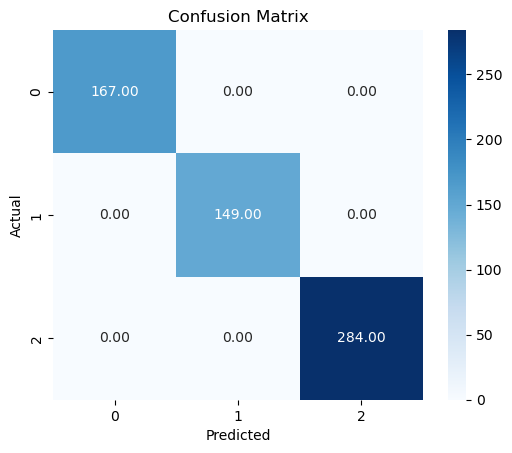

In [24]:
def evaluation_metrics(X_test, y_test, model):

    y_pred = model.predict(X_test)
    
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
    print(f"Precision Score: {precision_score(y_test, y_pred, average = 'weighted')}")
    print(f"Recall Score: {recall_score(y_test, y_pred, average = 'weighted')}")
    print(f"F1-Score: {f1_score(y_test, y_pred, average = 'weighted')}")

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot = True, fmt = ".2f", cmap = "Blues", square = True)
    plt.title("Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual");plt.show()

evaluation_metrics(X_test, y_test, best_model)

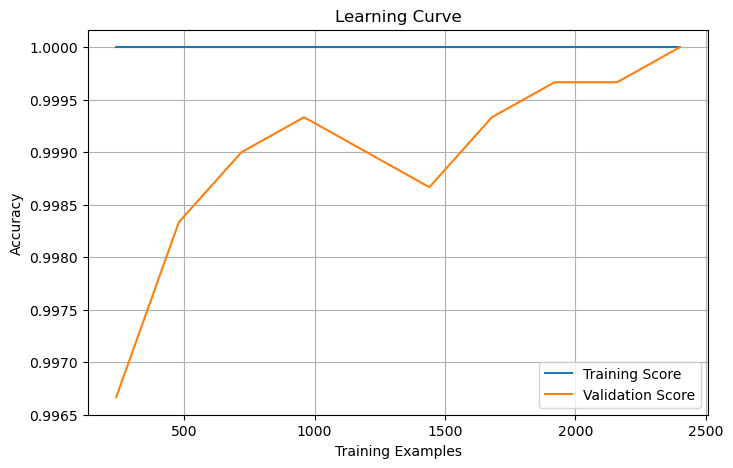

In [25]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Validation Score')

plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()